### ANN for regression, example 1, house energy bill estimation

#### Imports / modules

In [238]:
# pip install scikit-learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import metrics

# pip install tensorflow
import tensorflow as tf
import keras
from keras import layers

from sklearn.impute import KNNImputer

#### Loading the dataset

In [239]:
# load the data
df = pd.read_csv("../datasets/Life Expectancy Data.csv")

# let's quickly see the first 10 rows of data
df.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


Dataset originates from https://www.kaggle.com/datasets/vikramamin/life-expectancy-who.

The CSV file contains 22 variables and 2938 rows. It is data pertaining to life expectancy of different countries spanning from 2000 to 2015. The columns include

- Country:Country name
- Year: Year of the data
- Status: Country status of developed or developing
- Life_Expectancy: Life expectancy in age
- Adult_Mortality: Adult Mortality Rates of both sexes (probability of dying between 15 and 60 years per 1000 population)
- infant.deaths: Number of Infant Deaths per 1000 population
- Alcohol: Alcohol, recorded per capita (15+) consumption (in litres of pure alcohol)
- percentage.expenditure: Expenditure on health as a percentage of Gross Domestic Product per capita(%)
- Hepatitis.B: Hepatitis B (HepB) immunization coverage among 1-year-olds (%)
- Measles: number of reported cases per 1000 population
- BMI: Average Body Mass Index of entire population
- under.five.deaths: Number of under-five deaths per 1000 population
- Polio: Polio (Pol3) immunization coverage among 1-year-olds (%)
- Total.expenditure: General government expenditure on health as a percentage of total government expenditure (%)
- Diphtheria: Diphtheria tetanus toxoid and pertussis (DTP3) immunization coverage among 1-year-olds (%)room)
- HIV.AIDS: Deaths per 1 000 live births HIV/AIDS (0-4 years)
- GDP: Gross Domestic Product per capita (in USD)
- Population: Population of the country
- thinness..1.19.years: Prevalence of thinness among children and adolescents for Age 10 to 19 (% )
- thinness.5.9.years: Prevalence of thinness among children for Age 5 to 9(%)
- Income.composition.of.resources: Human Development Index in terms of income composition of resources (index  ranging from 0 to 1)
- Schooling: Number of years of Schooling(years)

In [240]:
# quickly check the first few rows of data
# to see what we have here
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [241]:
# There are a lot of rows with missing data.
# I'll use an imputer to fill in missing values.
# Otherwise a third of the datatset is unusable. 
null_data = df[df.isnull().any(axis=1)]

null_data

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
32,Algeria,2015,Developing,75.6,19.0,21,NaN,0.000000,95.0,63,...,95.0,NaN,95.0,0.1,4132.762920,39871528.0,6.0,5.8,0.743,14.4
44,Algeria,2003,Developing,71.7,146.0,20,0.34,25.018523,NaN,15374,...,87.0,3.60,87.0,0.1,294.335560,3243514.0,6.3,6.1,0.663,11.5
45,Algeria,2002,Developing,71.6,145.0,20,0.36,148.511984,NaN,5862,...,86.0,3.73,86.0,0.1,1774.336730,3199546.0,6.3,6.2,0.653,11.1
46,Algeria,2001,Developing,71.4,145.0,20,0.23,147.986071,NaN,2686,...,89.0,3.84,89.0,0.1,1732.857979,31592153.0,6.4,6.3,0.644,10.9
47,Algeria,2000,Developing,71.3,145.0,21,0.25,154.455944,NaN,0,...,86.0,3.49,86.0,0.1,1757.177970,3118366.0,6.5,6.4,0.636,10.7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2918,Zambia,2003,Developing,46.4,64.0,39,2.33,65.789974,NaN,881,...,85.0,8.18,83.0,18.2,429.158343,11421984.0,7.3,7.2,0.443,10.2
2919,Zambia,2002,Developing,45.5,69.0,41,2.44,54.043480,NaN,25036,...,85.0,6.93,84.0,18.4,377.135244,111249.0,7.4,7.3,0.433,10.0
2920,Zambia,2001,Developing,44.6,611.0,43,2.61,46.830275,NaN,16997,...,86.0,6.56,85.0,18.6,378.273624,1824125.0,7.4,7.4,0.424,9.8
2921,Zambia,2000,Developing,43.8,614.0,44,2.62,45.616880,NaN,30930,...,85.0,7.16,85.0,18.7,341.955625,1531221.0,7.5,7.5,0.418,9.6


In [242]:
# let's also fix and unify the spelling of column names (for my own sanity)

# Country,Year,Status,Life expectancy ,Adult Mortality,
# infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles ,
#  BMI ,under-five deaths ,Polio,Total expenditure,Diphtheria , HIV/AIDS,GDP,Population,
#  thinness  1-19 years, thinness 5-9 years,Income composition of resources,Schooling

headers = list(df.columns.values)
new_headers = []

for i in headers:
    clean_text = i.strip()

    if clean_text.isupper():
        new_headers.append(clean_text)

    else:
        new_headers.append(clean_text.title())    

    
print(new_headers)
df.columns = new_headers

['Country', 'Year', 'Status', 'Life Expectancy', 'Adult Mortality', 'Infant Deaths', 'Alcohol', 'Percentage Expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Under-Five Deaths', 'Polio', 'Total Expenditure', 'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'Thinness  1-19 Years', 'Thinness 5-9 Years', 'Income Composition Of Resources', 'Schooling']


In [243]:
print(f"Statuses: {df['Status'].nunique()}")

Statuses: 2


In [244]:
# this just converts the value of column to 0 or 1
# Binary: Status

# change status from developing/developed to 0/1

from sklearn.preprocessing import LabelEncoder
variables = ['Status']
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [245]:
print(f"Countries: {df['Country'].nunique()}")

Countries: 193


In [246]:
# Because there are 193 countries, we'll drop the column
df = df.drop(["Country", "Year"], axis=1)
df.head()

,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,BMI,Under-Five Deaths,Polio,Total Expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,1,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [247]:
# Next is the KNN Imputer. It only accepts numeric data, 
# so let's check datatype of all values

df.dtypes

Status                               int64
Life Expectancy                    float64
Adult Mortality                    float64
Infant Deaths                        int64
Alcohol                            float64
Percentage Expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
Under-Five Deaths                    int64
Polio                              float64
Total Expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
Thinness  1-19 Years               float64
Thinness 5-9 Years                 float64
Income Composition Of Resources    float64
Schooling                          float64
dtype: object

In [248]:
# using an imputer to fill the missing values
knn_imputer = KNNImputer(n_neighbors=5).set_output(transform="pandas")
# imputing the missing value with KNN imputer
df = knn_imputer.fit_transform(df)

# checking that it worked
print(df.isnull().sum())

Status                             0
Life Expectancy                    0
Adult Mortality                    0
Infant Deaths                      0
Alcohol                            0
Percentage Expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
Under-Five Deaths                  0
Polio                              0
Total Expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
Thinness  1-19 Years               0
Thinness 5-9 Years                 0
Income Composition Of Resources    0
Schooling                          0
dtype: int64


In [249]:
df

,Status,Life Expectancy,Adult Mortality,Infant Deaths,Alcohol,Percentage Expenditure,Hepatitis B,Measles,BMI,Under-Five Deaths,Polio,Total Expenditure,Diphtheria,HIV/AIDS,GDP,Population,Thinness 1-19 Years,Thinness 5-9 Years,Income Composition Of Resources,Schooling
0,1.0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,83.0,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,1.0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,86.0,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,1.0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,89.0,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,1.0,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,93.0,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,1.0,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,97.0,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2933,1.0,44.3,723.0,27.0,4.36,0.000000,68.0,31.0,27.1,42.0,67.0,7.13,65.0,33.6,454.366654,12777511.0,9.4,9.4,0.407,9.2
2934,1.0,44.5,715.0,26.0,4.06,0.000000,7.0,998.0,26.7,41.0,7.0,6.52,68.0,36.7,453.351155,12633897.0,9.8,9.9,0.418,9.5
2935,1.0,44.8,73.0,25.0,4.43,0.000000,73.0,304.0,26.3,40.0,73.0,6.53,71.0,39.8,57.348340,125525.0,1.2,1.3,0.427,10.0
2936,1.0,45.3,686.0,25.0,1.72,0.000000,76.0,529.0,25.9,39.0,76.0,6.16,75.0,42.1,548.587312,12366165.0,1.6,1.7,0.427,9.8


#### X/y -split

In [250]:
# perform X/y -split
# if you more than one independent variable, list them all here
# leave out the target variable (dependent variable)

# this is a nice and common trick => everything EXCEPT the target variable => support variables
X = df.drop(["Life Expectancy"], axis=1)

# have only the target variable here (dependent variable)
y = df['Life Expectancy']

#### Train/test/validation -split

In [251]:
# in Classic ML, we only had train/test -split
# in deep learning, we usually use validation-data also, for better
# optimization possibilities and better metrics

# unfortunately the scikit-learn's train_test_split doesn't support validation
# set split in itself.

# if you want to split the test set into two for a validation set too, try this trick:

# step 1, split the data into 70% (training data) and 30% (temporary data)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3)

# step 2, split the temporary data in HALF (0.5) => 15% test and 15% validation
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

In [252]:
## initialize the scaler and process X-values
## IN MOST CASES you can experiment with StandardScaler or MinMaxWScaler
## BUT ONLY USE ONE SCALER AT A TIME FOR SUPPORT VARIABLES
#from sklearn.preprocessing import StandardScaler
##from sklearn.preprocessing import MinMaxScaler
#
#sc = StandardScaler()
##sc = MinMaxScaler()
#
## FIT the scaler only to X-training data
## and only transform the test data with that
#X_train = sc.fit_transform(X_train)
#X_test = sc.transform(X_test)

In [ ]:
# The following codeblock, where scaling is done, is from AI. I had a longer conversation with it, 
# and this was effective in solving the issues I had, which I explain at the bottom.

from sklearn.preprocessing import StandardScaler

# 1. Initialize TWO separate scalers (This is the crucial change)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# 2. Process X-values (Features)
# FIT the scaler ONLY to X-training data, transform train, val, and test
X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)    # <-- You missed this one in your original code!
X_test = scaler_X.transform(X_test)

# 3. Process y-values (Target / Life Expectancy)
# Scikit-learn requires 2D arrays for scaling, so we must reshape the Pandas series
y_train = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_val = scaler_y.transform(y_val.values.reshape(-1, 1))
y_test = scaler_y.transform(y_test.values.reshape(-1, 1))

In [254]:
# you can inspect how the original values have now 
# switched to the scaled ones
X_train

array([[ 0.45839241, -0.7700664 , -0.25400591, ...,  0.27219672,
         0.9373654 ,  0.74553138],
       [-2.18153699, -0.84966047, -0.25400591, ..., -0.61173753,
         1.39098139,  1.01915887],
       [ 0.45839241,  1.35509518,  0.17068465, ...,  0.40478686,
        -0.18702318, -0.37938161],
       ...,
       [ 0.45839241, -1.18395555, -0.25400591, ...,  0.22800001,
         0.72503451,  0.19827641],
       [ 0.45839241,  0.4238446 , -0.22069685, ..., -0.63383589,
        -0.06638063, -0.13615718],
       [ 0.45839241, -0.65863471, -0.22902411, ..., -0.94321288,
         1.22208182,  1.23198025]], shape=(2056, 19))

#### Create a neural network structure

In [255]:
# create neural network

# save the amount of support variables into a helper variable
# so we don't have to update the input_shape all the time
variable_amount = len(X.columns)

# Define Sequential neural network model
# input shape has to match the amount of SUPPORT VARIABLES
# in other words => amount of columns in X 
# Tip: have at least the same number of nodes as in the input shape
# output layer in regression is always 1 node without activation function
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu", input_shape=(variable_amount,)),
        layers.Dense(32, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1)
    ]
)

# select the optimizer and loss function
# you can try rmsprop also as optimizer, or stochastic gradient descent
model.compile(optimizer='adam', loss='mse')

model.summary()

/mnt/corsair/repot/DeepLearning/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 16)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,409 (5.50 KB)

 Trainable params: 1,409 (5.50 KB)

 Non-trainable params: 0 (0.00 B)

dropout layer???

#### Train the neural network

In [256]:
# train/fit neural network with validation data
# see the instructions on the train/test -split above on how to split the data correctly
model.fit(x=X_train, y=y_train, epochs=100, validation_data=(X_val, y_val))

Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4941 - val_loss: 0.2681
Epoch 2/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 684us/step - loss: 0.2232 - val_loss: 0.2012
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 668us/step - loss: 0.1784 - val_loss: 0.1674
Epoch 4/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 0.1502 - val_loss: 0.1512
Epoch 5/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - loss: 0.1309 - val_loss: 0.1399
Epoch 6/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 653us/step - loss: 0.1202 - val_loss: 0.1308
Epoch 7/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 673us/step - loss: 0.1084 - val_loss: 0.1209
Epoch 8/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 666us/step - loss: 0.0998 - val_loss: 0.1142
Epoch 9/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 657us/step - loss: 0.0936 - val_loss: 0.1098
Epoch 10/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 677us/step - loss: 0.0874 - val_loss: 0.1127
Epoch 11/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 669us/step - loss: 0.0838 - val_loss: 0.1034
Epoch 12/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 

#### Training metrics in order to see if the model trained an works well

<Axes: >

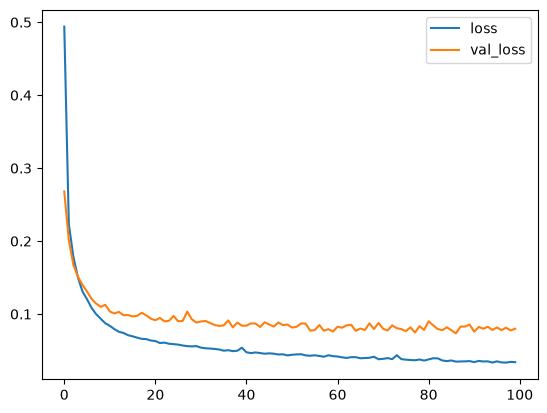

In [257]:
# let's use pandas for this (easy code)
# try to look if the model is actually training 
# => the error is going downwards
# if using validation data, you get two lines
# in this case, see if the lines follow a similar trend 
# (they don't always overlap with complex data, the trend is more important)
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()

In [258]:
# compare the final model loss/evaluation values
print("Test data evaluation:")
print(model.evaluate(X_test, y_test, verbose=0))
print("\nTrain data evaluation:")
print(model.evaluate(X_train, y_train, verbose=0))

Test data evaluation:
0.06395378708839417

Train data evaluation:
0.03175872191786766


#### Error metrics

In [259]:
# get test predictions
test_predictions = model.predict(X_test)

# reshape the data for easier comparison table
test_predictions = pd.Series(test_predictions.reshape(len(y_test),))
pred_df = pd.DataFrame(np.asarray(y_test), columns=['Test True Y'])
pred_df = pd.concat([pred_df, test_predictions], axis=1)
pred_df.columns = ['Test True Y', 'Model Predictions']

# print the comparison table - true values vs. model predicted values
# we can nicely see here how far off our model is in some cases
pred_df

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


,Test True Y,Model Predictions
0,0.978412,1.154699
1,-1.656996,-1.884505
2,0.905207,1.032722
3,1.260778,1.413008
4,0.622841,0.526754
...,...,...
436,0.330018,0.664338
437,1.218946,1.205756
438,0.277728,0.184982
439,0.434598,0.729865


<Axes: xlabel='Test True Y', ylabel='Model Predictions'>

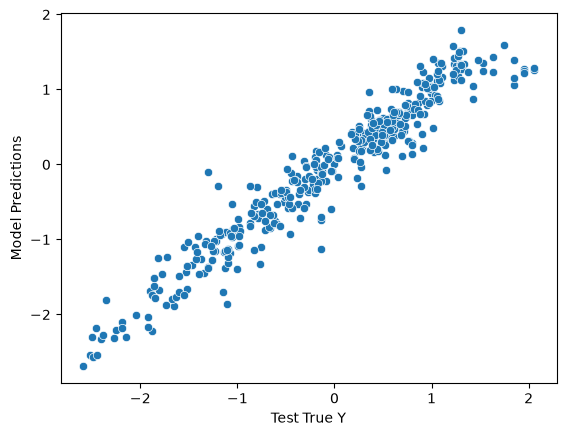

In [260]:
# these values follow a linear diagonal line = good predictions
# we basically compare the predicted values 
# to true test values and see the differences
sns.scatterplot(x='Test True Y', y='Model Predictions', data=pred_df)

In [261]:
# MAE - Mean average error
print("MAE")
print(round(metrics.mean_absolute_error(y_test, test_predictions), 2), "years")

# MSE - Mean square error
print("\nMSE")
print(round(metrics.mean_squared_error(y_test, test_predictions), 2), "years^2")

# RMSE - Root mean square error
print('\nRMSE:')
print(round(np.sqrt(metrics.mean_squared_error(y_test, test_predictions)), 2), "years")

# R-squared. 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
print('\nR-squared:')
print(round(metrics.r2_score(y_test, test_predictions), 2))

# Explained Variance Score => 0 = the model descibes the dataset poorly
# 1 = model describes the dataset perfectly
# high variance score = model is a good fit for the data 
# low variance score = model is not a good fit for the data
# the higher the score, the model is more able to explain the variation in the data
# if score is low, we might need more and better data
print("\nExplained variance score:")
print(round(metrics.explained_variance_score(y_test, test_predictions), 2))

MAE
0.18 years

MSE
0.06 years^2

RMSE:
0.25 years

R-squared:
0.93

Explained variance score:
0.93


In [263]:
## if the prediction distribution are far from normal distribution
## then the model is not probably good enough
## distplot is deprecating in future pandas-version
## unfortunately, there's no exact alternative to do this plot at the moment
#sns.distplot((y_test - test_predictions))
#plt.show()
#plt.close()

#### Try model in practice (with a new imaginary house)

In [264]:
# let's try with some new imaginary data
# this example uses the student performance index score dataset
# modify this as needed regarding your own dataset
tester_row = {
    'Status':1,
    'Adult Mortality': 61,
    'Infant Deaths': 11,
    'Alcohol':3.41,
    'Percentage Expenditure':200, 
    'Hepatitis B':9, 
    'Measles':0, 
    'BMI':21,
    'Under-Five Deaths':1, 
    'Polio': 95,
    'Total Expenditure': 6.5, 
    'Diphtheria': 99,
    'HIV/AIDS': 0.1, 
    'GDP': 3558.79, 
    'Population': 1633812.6, 
    'Thinness  1-19 Years': 2.4,
    'Thinness 5-9 Years': 7.8,
    'Income Composition Of Resources': 0.496, 
    'Schooling': 8.6
}

# convert to pandas format
tester_row = pd.DataFrame([tester_row])

In [ ]:
## get the prediction from the model and print out the result
#result = model.predict(tester_row)[0][0]
#
#print()
#print(f"Predicted life expectancy, with the given parameters:")
#print(f"{round(float(result), 2)} years.")
#print("----------------------------")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Predicted life expectancy, with the given parameters:
-14958.82 years.
----------------------------


In [266]:
# 1. Scale the raw input features using your ALREADY FITTED input scaler
# (Note: Use .transform(), never .fit_transform() on test data/single rows)
scaled_tester_row = scaler_X.transform(tester_row)
# 2. Get the prediction from the model (this will be a tiny, scaled number)
scaled_prediction = model.predict(scaled_tester_row)

# 3. Convert the scaled prediction back into real-world years
# We add [0][0] to extract the raw float from the NumPy array as discussed previously
real_world_years = scaler_y.inverse_transform(scaled_prediction)[0][0]

print(f"Predicted Life Expectancy: {real_world_years:.2f} years")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Predicted Life Expectancy: 74.88 years


Hooo boy. These were some dogwater results at first, but now it's a lot better. Initially, the R-squared was in the negative, somewhere between -0.1 and -300. SGD and adam got me worse results, so I used rmsprop. Changing epoch amounts didn't really do much. I tried changing the relu layer to leaky_relu, but everything gave me horrible results.

Then I attempted scaling. That worked wonderfully. R-squared jumped up to high 0.80's to low 0.90's, but the tester_row predicted my hypothetical person to live anywhere from 2 million to 6 million years. Then I asked AI to help. What I was doing wrong, is that the tester_row was using the unscaled values, thus R-squared was excellent and tester_row was extremely high. With the scaled values, this is much more realistic.